# Elife Paper 
## Figure 7: Lesion Experiment


In [9]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import json
import pickle
# import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
import yaml
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import Environment, NN, params_base, build_and_run
from dual_pathway_model.plotting_functions import plot_colors

In [2]:
wanted_parameters = ["BG_INTACT_DAYS"]

In [3]:
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "../Lesion_exp/results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    if param_name in wanted_parameters:
        selected_folders.append(folder)

print(selected_folders)

BG_INTACT_DAYS
[PosixPath('/home/asuryawanshi/Documents/Dual_Pathway_RL_songbird/Lesion_exp/results/params_BG_INTACT_DAYS')]


In [4]:
terminal_performance = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


In [5]:
print(meta['BG_INTACT_DAYS']['values'])

[5.0, 10.0, 20.0, 30.0, 35.0, 40.0, 50.0, 60.0, 65.0]


In [6]:
terminal_performance['BG_INTACT_DAYS'][:,-1,:]

array([[0.98656093,        nan,        nan],
       [0.99224204,        nan,        nan],
       [0.99012942,        nan,        nan],
       [0.99520386,        nan,        nan],
       [0.99946352,        nan,        nan],
       [0.98685682,        nan,        nan],
       [0.97853697,        nan,        nan],
       [0.98759231,        nan,        nan],
       [0.98862573,        nan,        nan],
       [0.65993456,        nan,        nan],
       [0.66599175,        nan,        nan],
       [0.98077495,        nan,        nan],
       [0.98963185,        nan,        nan],
       [0.98867837,        nan,        nan],
       [0.97624309,        nan,        nan],
       [0.9780168 ,        nan,        nan],
       [0.99409292,        nan,        nan],
       [0.99730967,        nan,        nan],
       [0.97619554,        nan,        nan],
       [0.98135445,        nan,        nan],
       [0.99900602,        nan,        nan],
       [0.99855678,        nan,        nan],
       [0.

[0, 4, 7]
0 5
1 35
2 60


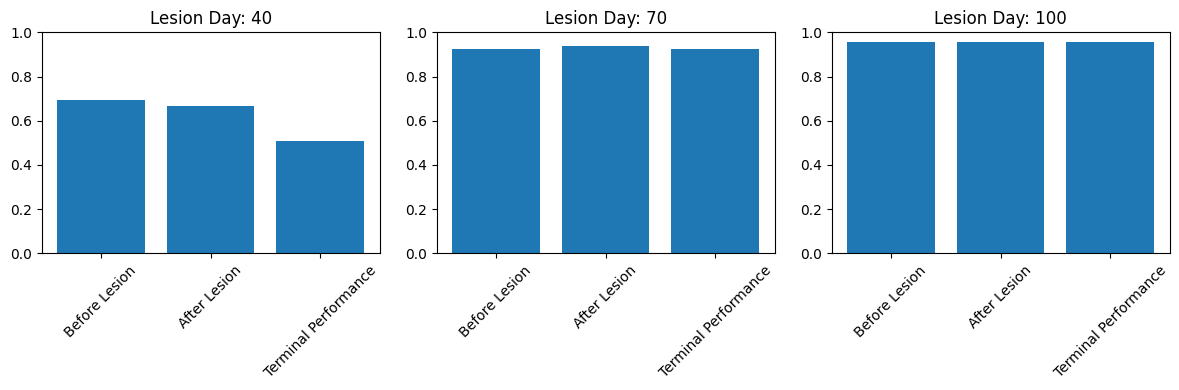

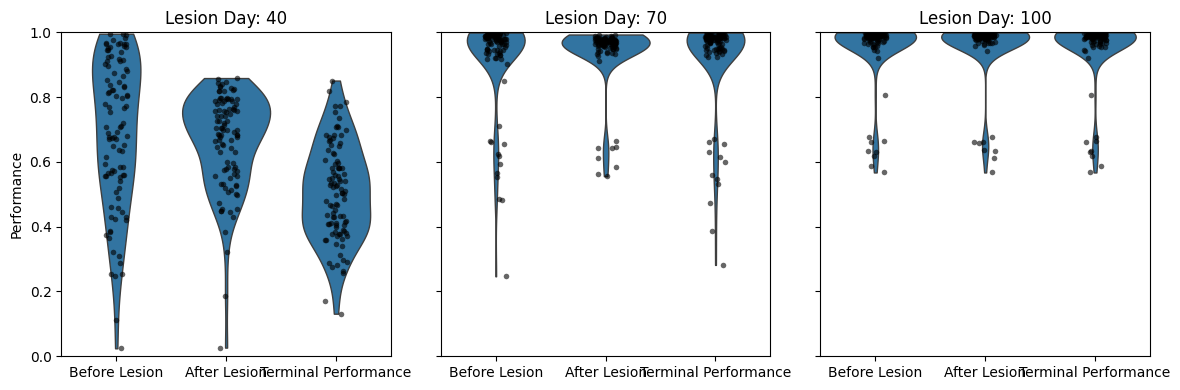

In [7]:
# Seeds x params x 3 metrics

wanted_days = [5, 35, 60]
lesion_day_list = meta['BG_INTACT_DAYS']['values']
# wanted indices 
wanted_indices = [lesion_day_list.index(day) for day in wanted_days]
print(wanted_indices)
plt.subplots(1,3, figsize=(12,4))

for day_idx, day in enumerate(wanted_days):
    print(day_idx,day)
    plt.subplot(1,3,day_idx+1)
    plt.bar(np.arange(terminal_performance['BG_INTACT_DAYS'].shape[2]), 
            terminal_performance['BG_INTACT_DAYS'][:,wanted_indices[day_idx],:].mean(axis=0))
    plt.xticks(np.arange(terminal_performance['BG_INTACT_DAYS'].shape[2]), 
            ['Before Lesion', 'After Lesion', 'Terminal Performance'], rotation=45)
    if day_idx == 2:
        plt.title(f'Lesion Day: {int(lesion_day_list[wanted_indices[day_idx]]+40)}')
    else:
        plt.title(f'Lesion Day: {int(lesion_day_list[wanted_indices[day_idx]]+35)}')
    plt.ylim(0, 1)
plt.tight_layout()
plt.show()

data = terminal_performance['BG_INTACT_DAYS']
conditions = ['Before Lesion', 'After Lesion', 'Terminal Performance']
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for day_idx, ax in enumerate(axes):
    # Extract data: shape (seeds, conditions)
    metric_data = data[:, wanted_indices[day_idx], :]  

    # Prepare data for seaborn
    plot_data = []
    plot_labels = []
    for j, cond in enumerate(conditions):
        plot_data.append(metric_data[:, j])
        plot_labels.extend([cond] * metric_data.shape[0])

    plot_data = np.concatenate(plot_data)

    # Violin plot
    sns.violinplot(
        x=plot_labels,
        y=plot_data,
        ax=ax,
        inner=None,
        cut=0,
        linewidth=1
    )

    # Individual points
    sns.stripplot(
        x=plot_labels,
        y=plot_data,
        ax=ax,
        color='black',
        size=4,
        jitter=True,
        alpha=0.6
    )
    if day_idx == 2:
            ax.set_title(f'Lesion Day: {int(lesion_day_list[wanted_indices[day_idx]] + 40)}')
    else:
        ax.set_title(f'Lesion Day: {int(lesion_day_list[wanted_indices[day_idx]] + 35)}')
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    if day_idx == 0:
        ax.set_ylabel('Performance')
    else:
        ax.set_ylabel('')

plt.tight_layout()
plt.show()

In [19]:
def plot_results_violin_conditions(
    data,                     # shape: seeds x lesion_days x conditions
    lesion_day_list,
    wanted_days,
    conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    xticklabel_rotation=30,
    figsize=(12, 4),
    print_success_rate=True
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    # --- indices ---
    wanted_indices = [lesion_day_list.index(day) for day in wanted_days]
    n_conditions = len(conditions)

    fig, axes = plt.subplots(
        1, len(wanted_days),
        figsize=figsize,
        sharey=True,
        constrained_layout=True
    )

    if len(wanted_days) == 1:
        axes = [axes]

    for ax, day_idx, day in zip(axes, wanted_indices, wanted_days):

        metric_data = data[:, day_idx, :]  # seeds x conditions

        # =======================
        # Success rate per condition
        # =======================
        success_rate = np.mean(metric_data > success_threshold, axis=0) * 100

        # =======================
        # Flatten for seaborn
        # =======================
        plot_data = []
        plot_labels = []
        for j, cond in enumerate(conditions):
            plot_data.append(metric_data[:, j])
            plot_labels.extend([cond] * metric_data.shape[0])

        plot_data = np.concatenate(plot_data)

        # =======================
        # Background success band
        # =======================
        ax.axhspan(
            success_threshold, 1.2,
            alpha=0.25,
            color="grey"
        )

        # =======================
        # Violin
        # =======================
        sns.violinplot(
            x=plot_labels,
            y=plot_data,
            inner=None,
            color="grey",
            linewidth=0,
            cut=0,
            bw_adjust=0.5,
            width=1,
            ax=ax
        )

        # Clip violins to right half
        for c in ax.collections:
            if hasattr(c, "get_paths"):
                for path in c.get_paths():
                    verts = path.vertices
                    x_center = np.median(verts[:, 0])
                    verts[:, 0] = np.maximum(verts[:, 0], x_center)

        # =======================
        # Strip plot (offset left)
        # =======================
        strip = sns.stripplot(
            x=plot_labels,
            y=plot_data,
            size=4,
            color=plot_colors['violin_plot_colors']['color_strip'],
            alpha=0.9,
            jitter=0.1,
            ax=ax
        )

        for coll in strip.collections:
            offsets = coll.get_offsets()
            offsets[:, 0] -= 0.2
            coll.set_offsets(offsets)

        # =======================
        # Threshold line
        # =======================
        ax.axhline(
            success_threshold, 0.02, .98,
            color='dimgray',
            linestyle='--',
            linewidth=2
        )

        # =======================
        # Success-rate bars (TOP)
        # =======================
        ax_top = inset_axes(
            ax,
            width="100%",
            height="80%",
            loc="upper center",
            bbox_to_anchor=(0, 1.002, 1, 0.22),
            bbox_transform=ax.transAxes,
            borderpad=0
        )

        xpos = np.arange(n_conditions) - 0.05

        ax_top.bar(
            xpos,
            success_rate,
            width=0.6,
            color='grey',
            alpha=0.75
        )

        if print_success_rate:
            for i, val in enumerate(success_rate):
                ax_top.text(
                    xpos[i],
                    val + 3,
                    int(val),
                    ha='center',
                    va='bottom',
                    fontsize=9
                )

        ax_top.set_ylim(0, 100)
        ax_top.set_yticks([0, 100])
        ax_top.set_yticklabels(['0', '100'], fontsize=9)
        ax_top.tick_params(axis='x', bottom=False, labelbottom=False)

        ax_top.spines['top'].set_visible(False)
        ax_top.spines['right'].set_visible(False)
        ax_top.spines['bottom'].set_visible(False)
        ax_top.spines['left'].set_visible(False)

        # =======================
        # Axis styling
        # =======================
        ax.set_ylim(0, 1.015)
        ax.set_yticks([0, success_threshold, 1])
        ax.set_yticklabels(['0', f'{success_threshold}', '1'], fontsize=11)

        ax.set_xlim(-0.45, n_conditions - 0.4)
        ax.set_xticks(np.arange(n_conditions) - 0.05)
        ax.set_xticklabels(
            conditions,
            rotation=xticklabel_rotation,
            ha='right',
            fontsize=11
        )

        ax.tick_params(axis='x', length=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        lesion_day_label = int(day + (40 if day == wanted_days[-1] else 35))
        ax.set_title(f"Lesion Day: {lesion_day_label}", fontsize=13)

    axes[0].set_ylabel("Performance", fontsize=14)

    return fig, axes

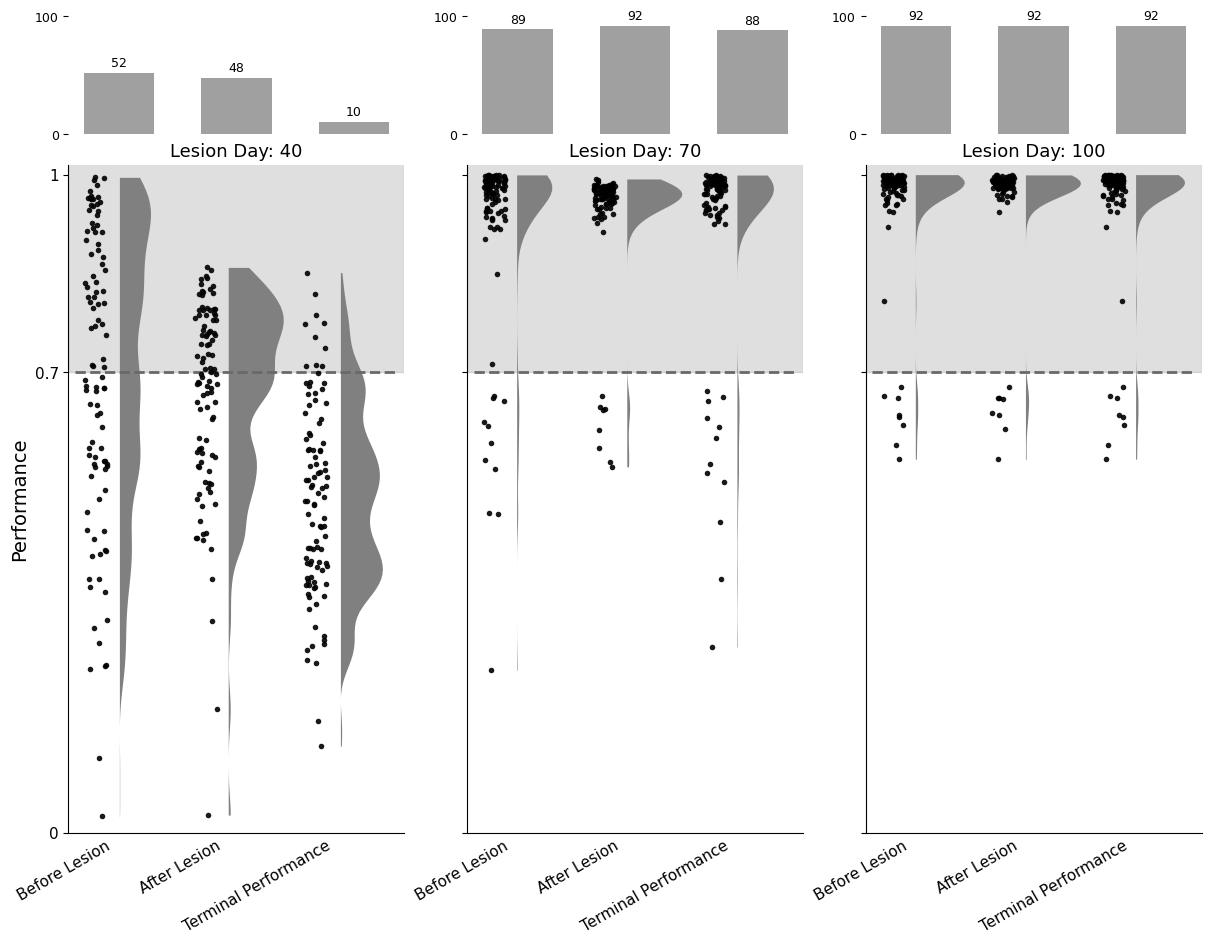

In [20]:
# Data you already have
data = terminal_performance['BG_INTACT_DAYS']
lesion_day_list = meta['BG_INTACT_DAYS']['values']
wanted_days = [5, 35, 60]
conditions = ['Before Lesion', 'After Lesion', 'Terminal Performance']

# Call the style-consistent plotting function
fig, axes = plot_results_violin_conditions(
    data=data,
    lesion_day_list=lesion_day_list,
    wanted_days=wanted_days,
    conditions=conditions,
    plot_colors=plot_colors,
    success_threshold=0.7,
    xticklabel_rotation=30,
    figsize=(12, 8)
)

plt.show()

In [7]:
terminal_performance['BG_INTACT_DAYS'].shape, meta['BG_INTACT_DAYS']

((100, 3, 3),
 {'parameter': 'BG_INTACT_DAYS',
  'section': 'params',
  'seeds': [44,
   144,
   835,
   5520,
   6821,
   9245,
   9907,
   13058,
   14414,
   15532,
   16009,
   16425,
   16761,
   17543,
   18638,
   20176,
   20463,
   20494,
   20898,
   23396,
   23932,
   24425,
   24551,
   24908,
   25377,
   25562,
   26459,
   27728,
   28573,
   28876,
   29046,
   32655,
   33508,
   33800,
   34750,
   34772,
   35227,
   35683,
   35872,
   37549,
   38811,
   40735,
   40937,
   41234,
   41488,
   41934,
   42119,
   42381,
   45150,
   45464,
   46144,
   47314,
   48850,
   49147,
   50565,
   51824,
   52101,
   53125,
   54746,
   56811,
   59465,
   61415,
   61804,
   62290,
   62321,
   62569,
   62910,
   63515,
   63671,
   65227,
   65491,
   67730,
   68254,
   68718,
   69229,
   69434,
   70160,
   70270,
   71855,
   72798,
   73163,
   73223,
   73404,
   73933,
   74022,
   75781,
   75807,
   76944,
   80640,
   81639,
   81711,
   85629,
   86407,
  

In [8]:
# print(data_cut[neighbouring_directories[0]])
# print(data_no_cut[neighbouring_directories[0]])

In [9]:
# data_cut["RA_SIG_SLOPE"].shape
# wanted_directories = ["WEIGHT_JUMP"]

In [10]:
# import seaborn as sns


# def plot_results_violin_3(data1, data2, data3, params, label):
#     # Scale returns to percentages
#     data1 = np.array(data1) * 100
#     data2 = np.array(data2) * 100
#     data3 = np.array(data3) * 100

#     # Sort parameter values and corresponding data
#     sorted_params = np.array(sorted(params))
#     sorted_indices = np.argsort(params)

#     data1 = data1[:, sorted_indices]
#     data2 = data2[:, sorted_indices]
#     data3 = data3[:, sorted_indices]

#     n_values = len(sorted_params)

#     # Arrays to store fraction above threshold
#     above_thresh1 = np.zeros(n_values)
#     above_thresh2 = np.zeros(n_values)
#     above_thresh3 = np.zeros(n_values)

#     data_flat1, data_flat2, data_flat3 = [], [], []
#     labels = []

#     for i in range(n_values):
#         col1 = data1[:, i]
#         col2 = data2[:, i]
#         col3 = data3[:, i]

#         above_thresh1[i] = np.sum(col1 > 70) / len(col1)
#         above_thresh2[i] = np.sum(col2 > 70) / len(col2)
#         above_thresh3[i] = np.sum(col3 > 70) / len(col3)

#         data_flat1.extend(col1)
#         data_flat2.extend(col2)
#         data_flat3.extend(col3)

#         labels.extend([sorted_params[i]] * len(col1))  # Same label repeated

#     # Start plotting
#     plt.figure(figsize=(14, 7))

#     # Plot violins (no label)
#     sns.violinplot(x=labels, y=data_flat1, inner=None, color='skyblue', alpha=0.4, linewidth=1)
#     sns.violinplot(x=labels, y=data_flat2, inner=None, color='orange', alpha=0.3, linewidth=1)
#     sns.violinplot(x=labels, y=data_flat3, inner=None, color='limegreen', alpha=0.3, linewidth=1)

#     # Plot stripplots (no label inside)
#     sns.stripplot(x=labels, y=data_flat1, size=2, color='skyblue', alpha=0.9, jitter=0.25)
#     sns.stripplot(x=labels, y=data_flat2, size=2, color='orange', alpha=0.9, jitter=0.25)
#     sns.stripplot(x=labels, y=data_flat3, size=2, color='limegreen', alpha=0.9, jitter=0.25)

#     # Threshold line
#     plt.axhline(70, color='red', linestyle='--')

#     # Annotate above threshold percentages
#     for i in range(n_values):
#         plt.text(i, 98, f"{100 * above_thresh1[i]:.1f}%", ha='center', va='bottom', fontsize=7, color='blue')
#         plt.text(i, 92, f"{100 * above_thresh2[i]:.1f}%", ha='center', va='bottom', fontsize=7, color='red')
#         plt.text(i, 86, f"{100 * above_thresh3[i]:.1f}%", ha='center', va='bottom', fontsize=7, color='green')

#     # Manual legend
#     import matplotlib.patches as mpatches
#     legend_elements = [
#         mpatches.Patch(color='skyblue', label='Before Lesion'),
#         mpatches.Patch(color='orange', label='After Lesion'),
#         mpatches.Patch(color='limegreen', label='End'),
#         mpatches.Patch(color='red', label='Threshold = 70', linestyle='--')
#     ]
#     plt.legend(handles=legend_elements)

#     # Labels etc
#     plt.xlabel('Parameter set', fontsize=14)
#     plt.ylabel('Return %', fontsize=14)
#     plt.ylim(0, 105)
#     plt.title(f"Variability of performance for {label} with noise", fontsize=20)

#     plt.tight_layout()
#     plt.show()


# plot_results_violin_3(
#     data_b4cut['BG_INTACT_DAYS'],
#     data_aftercut['BG_INTACT_DAYS'],
#     data_end['BG_INTACT_DAYS'],
#     parameter_values['BG_INTACT_DAYS'],
#     label="cut"
# )


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_results_bar_3(data1, data2, data3, params, label):
    # Scale returns to percentages
    data1 = np.array(data1) * 100
    data2 = np.array(data2) * 100
    data3 = np.array(data3) * 100

    # Sort parameter values and corresponding data
    sorted_params = np.array(sorted(params))
    sorted_indices = np.argsort(params)

    data1 = data1[:, sorted_indices]
    data2 = data2[:, sorted_indices]
    data3 = data3[:, sorted_indices]

    n_values = len(sorted_params)

    # Arrays to store fraction above threshold
    above_thresh1 = np.zeros(n_values)
    above_thresh2 = np.zeros(n_values)
    above_thresh3 = np.zeros(n_values)

    for i in range(n_values):
        col1 = data1[:, i]
        col2 = data2[:, i]
        col3 = data3[:, i]

        above_thresh1[i] = np.sum(col1 > 70) / len(col1)
        above_thresh2[i] = np.sum(col2 > 70) / len(col2)
        above_thresh3[i] = np.sum(col3 > 70) / len(col3)

    # Start plotting
    plt.figure(figsize=(14, 7))

    bar_width = 0.25
    x = np.arange(n_values)

    plt.bar(x - bar_width, 100 * above_thresh1, width=bar_width, color='grey', alpha=0.6, edgecolor='black', label='Before Lesion')
    plt.bar(x,             100 * above_thresh2, width=bar_width, color='slateblue', alpha=0.6, edgecolor='black', label='After Lesion')
    plt.bar(x + bar_width, 100 * above_thresh3, width=bar_width, color='darkblue', alpha=0.6, edgecolor='black', label='End of learning')

    # plt.axhline(70, color='red', linestyle='--', label='Threshold = 70')

    # Labels and title
    plt.xlabel('Day of Lesion', fontsize=20)
    plt.ylabel('% of trials finding global maxima', fontsize=20)
    # plt.title(f"", fontsize=20)
    plt.xticks(x, [int(p+30) for p in sorted_params], fontsize =14)    # type: ignore
    # remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.ylim(0, 105)
    plt.legend(loc = 2, fontsize=14)
    plt.tight_layout()
    plt.show()

# Usage example:
plot_results_bar_3(
    terminal_performance['BG_INTACT_DAYS'][:, :,0],
    terminal_performance['BG_INTACT_DAYS'][:, :, 1],
    terminal_performance['BG_INTACT_DAYS'][:, :, 2],
    meta['BG_INTACT_DAYS'],
    label="cut"
)


IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
import matplotlib.patches as mpatches

def plot_results_bar_3(data1, data2, data3, params, label, ax, filter_days=None):   
    data1 = np.array(data1) * 100
    data2 = np.array(data2) * 100
    data3 = np.array(data3) * 100

    sorted_params = np.array(sorted(params))
    sorted_indices = np.argsort(params)

    data1 = data1[:, sorted_indices]
    data2 = data2[:, sorted_indices]
    data3 = data3[:, sorted_indices]
    sorted_params = sorted_params  # Sorted

    if filter_days is not None:
        # Convert filter_days back to original params (subtract 30)
        filter_params = [d - 30 for d in filter_days]
        mask = np.isin(sorted_params, filter_params)
        data1 = data1[:, mask]
        data2 = data2[:, mask]
        data3 = data3[:, mask]
        sorted_params = sorted_params[mask]

    n_values = len(sorted_params)

    above_thresh1 = np.zeros(n_values)
    above_thresh2 = np.zeros(n_values)
    above_thresh3 = np.zeros(n_values)

    for i in range(n_values):
        col1 = data1[:, i]
        col2 = data2[:, i]
        col3 = data3[:, i]

        above_thresh1[i] = np.sum(col1 > 70) / len(col1)
        above_thresh2[i] = np.sum(col2 > 70) / len(col2)
        above_thresh3[i] = np.sum(col3 > 70) / len(col3)

    bar_width = 0.1
    x = np.arange(n_values)

    ax.bar(x - 0.25, 100 * above_thresh1, width=bar_width, color='grey', alpha=0.9, edgecolor='black', label='Before Lesion')
    ax.bar(x,             100 * above_thresh2, width=bar_width, color='skyblue', alpha=0.9, edgecolor='black', label='After Lesion')
    ax.bar(x + 0.25, 100 * above_thresh3, width=bar_width, color='dodgerblue', alpha=0.9, edgecolor='black', label='End of learning')

    # ax.set_xlabel('Day of Lesion', fontsize=14)
    ax.set_ylabel('% of trials finding \nglobal maxima', fontsize=20)
    ax.set_xticks([])
    ax.set_yticks([0, 100])
    ax.tick_params(labelsize=20)
    # ax.set_xticklabels([int(p+30) for p in sorted_params], fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=12)
    # ax.set_title(f"Panel 1: {label}", fontsize=16)


### C.

In [25]:


# def plot_results_violin_3(data1, data2, data3, params, label, ax, filter_days=None):    
#     data1 = np.array(data1) * 100
#     data2 = np.array(data2) * 100
#     data3 = np.array(data3) * 100

#     sorted_params = np.array(sorted(params))
#     sorted_indices = np.argsort(params)

#     data1 = data1[:, sorted_indices]
#     data2 = data2[:, sorted_indices]
#     data3 = data3[:, sorted_indices]
#     sorted_params = sorted_params

#     if filter_days is not None:
#         filter_params = [d - 30 for d in filter_days]
#         mask = np.isin(sorted_params, filter_params)
#         data1 = data1[:, mask]
#         data2 = data2[:, mask]
#         data3 = data3[:, mask]
#         sorted_params = sorted_params[mask]

#     n_values = len(sorted_params)

#     above_thresh1 = np.zeros(n_values)
#     above_thresh2 = np.zeros(n_values)
#     above_thresh3 = np.zeros(n_values)

#     data_flat1, data_flat2, data_flat3 = [], [], []
#     labels_list = []

#     for i in range(n_values):
#         col1 = data1[:, i]
#         col2 = data2[:, i]
#         col3 = data3[:, i]

#         above_thresh1[i] = np.sum(col1 > 70) / len(col1)
#         above_thresh2[i] = np.sum(col2 > 70) / len(col2)
#         above_thresh3[i] = np.sum(col3 > 70) / len(col3)

#         data_flat1.extend(col1)
#         data_flat2.extend(col2)
#         data_flat3.extend(col3)

#         labels_list.extend([int(sorted_params[i]+30)] * len(col1))

#     # Convert to DataFrame-like for seaborn
#     import pandas as pd
#     df = pd.DataFrame({
#         'Param': labels_list * 3,
#         'Return %': data_flat1 + data_flat2 + data_flat3,
#         'Condition': ['Before'] * len(data_flat1) + ['After'] * len(data_flat2) + ['End'] * len(data_flat3)
#     })

#     sns.violinplot(data=df, x='Param', y='Return %', hue='Condition', ax=ax, split=False, inner=None, linewidth=1, alpha=0.6, palette={'Before': 'grey', 'After': 'skyblue', 'End': 'dodgerblue'})
#     sns.stripplot(data=df, x='Param', y='Return %', hue='Condition', ax=ax, size=3, jitter=0.30, dodge=True, palette={'Before': 'black', 'After': 'black', 'End': 'black'}, legend=False)

#     ax.axhline(70, xmin= 0.025, xmax = 0.975, color='red', linestyle='--', label='Threshold = 70')  
#     ax.set_xlabel('Day of Lesion', fontsize=20)
#     ax.set_ylabel('Returns', fontsize=20)
#     ax.set_ylim(0, 105)
#     ax.set_yticks([0, 100], [0,1])
#     ax.tick_params(labelsize=20)
#     # ax.set_title(f"Panel 2: Variability of {label} performance", fontsize=16)
#     # top and right spine remove
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.legend('off')

#     # handles = [
#     #     # mpatches.Patch(color='skyblue', label='Before Lesion'),
#     #     # mpatches.Patch(color='slateblue', label='After Lesion'),
#     #     # mpatches.Patch(color='darkblue', label='End'),
#     #     mpatches.Patch(color='red', label='Threshold = 70')
#     # ]
#     # ax.legend(handles=handles, fontsize=10)

# # def plot_rewards()

# # =================
# # Create the figure and subplots
# fig, axs = plt.subplots(2, 1, figsize=(20, 10))
# fig.subplots_adjust(hspace=0.4, wspace=0.3)

# # Only show days 40, 60, 90 (i.e., params 10, 30, 60)
# filter_days = [40, 60, 90]

# plot_results_bar_3(
#     data_b4cut['BG_INTACT_DAYS'],
#     data_aftercut['BG_INTACT_DAYS'],
#     data_end['BG_INTACT_DAYS'],
#     parameter_values['BG_INTACT_DAYS'],
#     label="cut",
#     ax=axs[0],
#     filter_days=filter_days
# )

# plot_results_violin_3(
#     data_b4cut['BG_INTACT_DAYS'],
#     data_aftercut['BG_INTACT_DAYS'],
#     data_end['BG_INTACT_DAYS'],
#     parameter_values['BG_INTACT_DAYS'],
#     label="cut",
#     ax=axs[1],
#     filter_days=filter_days
# )


# # Leave Panel 3 and 4 empty for now
# # axs[0].axis('off')
# # axs[1].axis('off')

# plt.tight_layout()
# plt.show()


### B.

In [ ]:
with open('params.json', "r") as f:
    parameters = json.load(f)
    N_SYLL = parameters['params']['N_SYLL']
    TRIALS = parameters['params']['TRIALS']
    DAYS = parameters['params']['DAYS']

print(f"N_SYLL: {N_SYLL}, TRIALS: {TRIALS}, DAYS: {DAYS}")  

N_SYLL: 20, TRIALS: 1000, DAYS: 61


In [2]:
# def plot_rewards()

RANDOM_SEED = 42
desired_days = [10, 30, 60]  # Only process these DAY values

neighboring_directories = find_neighboring_directories()


In [22]:

# # directory where robustness.py lives
# HERE = Path(__file__).resolve().parent
HERE = Path.cwd()          # notebook directory
# results_dir = HERE / "../Lesion_exp/results"
LESION_CONFIG = HERE / "../Lesion_exp/lesion_params.yaml"

with open(LESION_CONFIG, "r") as f:
    lesion_cfg = yaml.safe_load(f)

print(f"Lesion parameters loaded from {LESION_CONFIG}")

NOS_SEEDS = 1
time_per_iter = 5.5
state = 5
np.random.seed(state)
seeds = np.random.randint(0, 100000, NOS_SEEDS)
seeds.sort()

# TIME ESTIMATE
total_iterations = sum(len(param_info["values"]) for param_info in lesion_cfg.values()) * NOS_SEEDS
total_time_hours = (total_iterations * time_per_iter) / 3600
print(f"Estimated total time for robustness analysis: {total_time_hours:.2f} hours")

for param_name, param_info in lesion_cfg.items():
    section = param_info["section"]
    values = param_info["values"]
    
    print(f"\nRunning robustness for {section}.{param_name}")

    terminal_performance = np.zeros((NOS_SEEDS, len(values), 3))
    outputs_all = []
    for val_idx, val in enumerate(values):
        val = float(val)  # ensure val is a float for YAML serialization
        print(f" -- {param_name} = {val}")

        parameters = update_params(
            params_base,
            **{
                f"{section}.{param_name}": val,
                "params.N_SYLL": 1,
                # "params.DAYS": 2, # for quick testing
            }
        )

        if parameters["params"]["N_SYLL"] != 1:
            raise ValueError("N_SYLL must be 1 for robustness analysis.")
        for seed_idx, seed in enumerate(seeds):
            
            outputs = build_and_run(seed, parameters, NN, lesion = True, output_reward = True, output_action= True)
            # terminal_performance[seed_idx, val_idx, :] = terminal_perf, before_lesion, after_lesion
            outputs_all.append(outputs)
            # print(f"    Seed {seed} -> {terminal_perf}, {before_lesion}, {after_lesion}")

    # results_dir = HERE / "results" / f"{section}_{param_name}"
    # results_dir.mkdir(parents=True, exist_ok=True)

    # np.save(results_dir / "terminal_performance.npy", terminal_performance)

    # with open(results_dir / "meta.yaml", "w") as f:
    #     yaml.safe_dump(
    #         {
    #             "parameter": param_name,
    #             "section": section,
    #             "values": [float(v) for v in values],  # convert to Python float
    #             "seeds": [int(s) for s in seeds],      # convert to Python int
    #             "shape": terminal_performance.shape
    #         },
    #         f
    #     )
    # print(f"Results saved to {results_dir}")


Lesion parameters loaded from c:\Users\aSuryawanshi\Documents\Codes\Dual_Pathway_RL_songbird\Figures\..\Lesion_exp\lesion_params.yaml
Estimated total time for robustness analysis: 0.01 hours

Running robustness for params.BG_INTACT_DAYS
 -- BG_INTACT_DAYS = 5.0
 Random seed is 35683


100%|██████████| 61/61 [00:07<00:00,  8.03it/s]


 -- BG_INTACT_DAYS = 10.0
 Random seed is 35683


100%|██████████| 61/61 [00:07<00:00,  8.03it/s]


 -- BG_INTACT_DAYS = 20.0
 Random seed is 35683


...

100%|██████████| 61/61 [00:07<00:00,  7.97it/s]


 -- BG_INTACT_DAYS = 60.0
 Random seed is 35683


100%|██████████| 61/61 [00:07<00:00,  8.00it/s]


 -- BG_INTACT_DAYS = 65.0
 Random seed is 35683


100%|██████████| 61/61 [00:07<00:00,  7.94it/s]


In [ ]:


# for directory in neighboring_directories:
#     if directory in wanted_directories:
#         nos_parameters = 0
#         for potential_filename in os.listdir(directory):
#             if potential_filename.startswith("parameters_") and potential_filename.endswith(".json"):
#                 # Extract day from filename: parameters_<day>.json
#                 try:
#                     param_day = int(potential_filename.split("_")[1].split(".")[0])
#                 except ValueError:
#                     print(f"Skipping file {potential_filename}: cannot extract day")
#                     continue
#                 if param_day not in desired_days:
#                     print(f"Skipping file {potential_filename}: day {param_day} not in desired days {desired_days}")
#                     continue
#                 nos_parameters += 1

#         print(f"Number of parameters: {nos_parameters} for directory {directory}")
#         if nos_parameters == 0:
#             print(f"No matching files in {directory}")
#             continue

#         param_order = np.zeros((nos_parameters))
#         actions = np.zeros((nos_parameters, DAYS, TRIALS, 1, 2))
#         rewards = np.zeros((nos_parameters, DAYS, TRIALS, 1))
#         j = 0

#         for potential_filename in os.listdir(directory):
#             if potential_filename.startswith("parameters_") and potential_filename.endswith(".json"):
#                 try:
#                     param_day = int(potential_filename.split("_")[1].split(".")[0])
#                 except ValueError:
#                     continue
#                 if param_day not in desired_days:
#                     continue

#                 print(f"Processing file: {potential_filename} with index {j}")
#                 if j >= nos_parameters:
#                     print(f"Skipping file {potential_filename} as index {j} exceeds nos_parameters {nos_parameters}")
#                     continue

#                 full_filename = os.path.join(directory, potential_filename)
#                 print(full_filename)
#                 with open(full_filename, "r") as f:
#                     parameters = json.load(f)
#                     N_SYLL = parameters['params']['N_SYLL']
#                     if N_SYLL != 1:
#                         raise ValueError('nos syllables needs to be 1')
#                     print(f"Opening JSON file: {full_filename}")
#                     annealing_val = parameters['params']['ANNEALING']
#                     obj = Environment(RANDOM_SEED, parameters, NN)
#                     obj.run(parameters, True)
#                     actions[j, :, :] = obj.actions
#                     rewards[j, :] = obj.rewards
#                     param_order[j] = param_day
#                     j += 1

# # Plot the results after the loop finishes
# plot_rewards_and_actions(rewards, actions, param_order, DAYS, TRIALS)


In [23]:
outputs_all[1]['actions'].shape, outputs_all[0]['rewards'].shape

((61, 1000, 1, 2), (61, 1000, 1))

In [ ]:
wanted_days

1

In [24]:
rewards_array = []
actions_array = []
for i in range(len(outputs_all)):
    rewards_array.append(outputs_all[i]['rewards'])
    actions_array.append(outputs_all[i]['actions'])
rewards_array = np.array(rewards_array)
actions_array = np.array(actions_array)

In [25]:
actions_array.shape, rewards_array.shape

((9, 61, 1000, 1, 2), (9, 61, 1000, 1))

DAYS: 61, TRIALS: 1000
Lesion at day 5
Lesion at day 35
Lesion at day 60


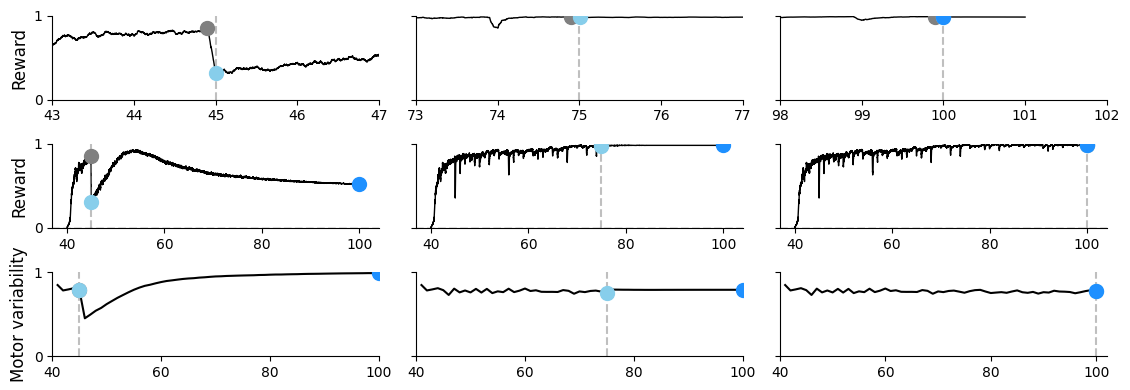

In [27]:

def running_mean(x, N=5):
        """ Returns the running average of an array. """
        rm = np.convolve(x, np.ones(N)/N, mode='valid')
        padded_rm = np.ones(np.shape(x)) * rm[-1]
        padded_rm[:rm.size] = rm

        return padded_rm

def plot_rewards_and_actions(rewards, actions, param_order, days, trials, smoothing=100):
    # Define colors for the points
    point_colors = {'Before': 'grey', 'After': 'skyblue', 'End': 'dodgerblue'}

    rewards = rewards.squeeze()  # (params, days, trials)
    actions = actions.squeeze()  # (params, days, trials, 2)

    fig, axs = plt.subplots(3, len(param_order), figsize=(4 * len(param_order), 4), sharey='row')
    if len(param_order) == 1:
        axs = np.expand_dims(axs, axis=1)

    for i, param_idx in enumerate(np.argsort(param_order)):
        lesion_day = param_order[param_idx]
        print(f"Lesion at day {lesion_day}")

        # Flatten data
        reward_data = rewards[param_idx].reshape(-1)
        action_data = actions[param_idx].reshape(-1, 2)
        time_axis = np.linspace(0, days, days * trials)

        # Smooth data
        smooth_reward = running_mean(reward_data, smoothing)
        smooth_x = running_mean(action_data[:, 0], smoothing)
        smooth_y = running_mean(action_data[:, 1], smoothing)
        smooth_time = time_axis[:len(smooth_reward)]

        # Plot full trajectories in black
        axs[0, i].plot(smooth_time + 40, smooth_reward, color='black', lw=1)
        axs[1, i].plot(smooth_time + 40, smooth_reward, color='black', lw=1)
        # axs[1, i].plot(smooth_time + 40, smooth_x, color='black', lw=1)
        # axs[1, i].plot(smooth_time + 40, smooth_y, color='black', lw=1, alpha=0.5)
        axs[0, i].axvline(lesion_day + 40, linestyle='--', color='grey', alpha=0.5)  # type: ignore
        axs[1, i].axvline(lesion_day + 40, linestyle='--', color='grey', alpha=0.5)  # type: ignore
        # Get 3 time points: before, after, end
        event_days = {'Before': lesion_day-0.1, 'After': lesion_day, 'End': 60}
        for label, day in event_days.items():
            # Find closest time in smoothed array
            mask = np.abs(smooth_time - day) < 0.1
            # axs[0, i].axvline(smooth_time[mask][0] + 40, linestyle='--', color=point_colors[label], alpha=0.5)          
            # axs[0, i].scatter(smooth_time[mask] + 40, smooth_reward[mask], color=point_colors[label], s=5, zorder=5)
            axs[0, i].scatter(smooth_time[int(day*TRIALS)] + 40, smooth_reward[int(day*TRIALS)], color=point_colors[label], s=100, zorder=5)
            # axs[1, i].scatter(smooth_time + 30, smooth_reward, color=point_colors[label], s=5, zorder=5)
            axs[1, i].scatter(smooth_time[int(day*TRIALS)] + 40, smooth_reward[int(day*TRIALS)], color=point_colors[label], s=100, zorder=5)
            # axs[1, i].scatter(smooth_time[mask] + 40, smooth_reward[mask], color=point_colors[label], s=5, zorder=5)
            # axs[1, i].scatter(smooth_time[mask] + 40, smooth_x[mask], color=point_colors[label], s=5, zorder=5)
            # axs[1, i].scatter(smooth_time[mask] + 40, smooth_y[mask], color=point_colors[label], s=5, zorder=5, alpha=0.5)

        # Formatting
        axs[0, i].set_xlim(40+lesion_day - 2, 40+lesion_day + 2)
        axs[0, i].set_ylim(0, 1)
        axs[0, i].set_yticks([0, 1])
        axs[0, i].tick_params(labelsize=10)
        # axs[0, i].set_xticks(40 + np.arange(0, days + 1, 20))
        axs[0, i].spines[['right', 'top']].set_visible(False)
        # axs[0, i].set_title(f"Lesion at {lesion_day}d", fontsize=12)

        axs[1, i].axhline(0, linestyle='--', color='black', alpha=0.1)
        axs[1, i].set_ylim(0, 1)
        axs[1, i].set_yticks([0, 1], [0, 1])
        axs[1, i].tick_params(labelsize=10)
        axs[1, i].set_xticks(40 + np.arange(0, days + 1, 20))
        axs[1, i].spines[['right', 'top']].set_visible(False)

        if i == 0:
            axs[0, i].set_ylabel("Reward", fontsize=12)
            axs[1, i].set_ylabel("Reward", fontsize=12)

        # Motor variability 
        
        motor_var = np.std(actions[param_idx], axis=2)  # (days, 2)
        mean_motor_var = np.mean(motor_var, axis=1)  # (days
        axs[2, i].plot(np.arange(1, days + 1) + 40, mean_motor_var, color='black')
        axs[2, i].axvline(lesion_day + 40, linestyle='--', color='grey', alpha=0.5)  # type: ignore
        for label, day in event_days.items():
            mask = np.abs(np.arange(1, days + 1) - day) < 0.1
            axs[2, i].scatter(np.arange(1, days + 1)[mask] + 40, mean_motor_var[mask], color=point_colors[label], s=100, zorder=5)
        axs[2, i].set_xlim(40+lesion_day - 2, 40+lesion_day + 2)
        axs[2, i].set_ylim(0, 1)
        axs[2, i].set_yticks([0, 1])
        axs[2, i].set_xticks(40 + np.arange(0, days + 1, 20))
        axs[2, i].tick_params(labelsize=10)
        axs[2, i].spines[['right', 'top']].set_visible(False)
        if i == 0:
            axs[2, i].set_ylabel("Motor variability", fontsize=12)

    # Legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markersize=8, label=lbl)   # type: ignore
               for lbl, col in point_colors.items()] # type: ignore
    # fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=12)

    plt.tight_layout(rect=[0, 0, 0.95, 1])  #type: ignore
    plt.show()



TRIALS = outputs_all[0]['rewards'].shape[1]
DAYS = outputs_all[0]['rewards'].shape[0]
print(f"DAYS: {DAYS}, TRIALS: {TRIALS}")

# plot_rewards_and_actions(rewards_output, actions, param_order, DAYS, TRIALS)
plot_rewards_and_actions(rewards_array[wanted_indices], actions_array[wanted_indices], wanted_days , DAYS, TRIALS)